**Tesla_Stock_Prediction_Project**

In [6]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [1]:
## STEP 1 — IMPORT LIBRARIES

# Import Required Libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import MinMaxScaler

# Evaluation Metrics
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    LSTM,
    SimpleRNN,
    Dropout
)

# Callbacks
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

# Plot Style
plt.style.use('ggplot')

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
## STEP 2 — LOAD DATASET

from google.colab import files
uploaded = files.upload()

Saving TSLA.csv to TSLA.csv


In [5]:
import io

df = pd.read_csv(io.StringIO(uploaded['TSLA.csv'].decode('utf-8')))
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


In [7]:
## STEP 3 — DATA OVERVIEW

# Shape of Dataset
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 2416
Columns: 7


In [8]:
# Column Names
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

In [9]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2416 non-null   object 
 1   Open       2416 non-null   float64
 2   High       2416 non-null   float64
 3   Low        2416 non-null   float64
 4   Close      2416 non-null   float64
 5   Adj Close  2416 non-null   float64
 6   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 132.3+ KB


In [10]:
# Statistical Summary
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2416.000000,2416.000000,2416.000000,2416.000000,2416.000000,2.416000e+03
mean,186.271147,189.578224,182.916639,186.403651,186.403651,5.572722e+06
std,118.740163,120.892329,116.857591,119.136020,119.136020,4.987809e+06
min,16.139999,16.629999,14.980000,15.800000,15.800000,1.185000e+05
25%,34.342498,34.897501,33.587501,34.400002,34.400002,1.899275e+06
50%,213.035004,216.745002,208.870002,212.960007,212.960007,4.578400e+06
75%,266.450012,270.927513,262.102501,266.774994,266.774994,7.361150e+06
max,673.690002,786.140015,673.520020,780.000000,780.000000,4.706500e+07


In [11]:
## STEP 4 — DATA CLEANING

# Checking Missing Values
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


In [12]:
# Checking Duplicate Records
df.duplicated().sum()

np.int64(0)

In [13]:
# Convert Date Column into Datetime Format
df['Date'] = pd.to_datetime(df['Date'])
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


In [14]:
# Setting Date as Index
df.set_index('Date', inplace=True)
df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


In [15]:
# Sort Dataset Chronologically
df.sort_index(inplace=True)

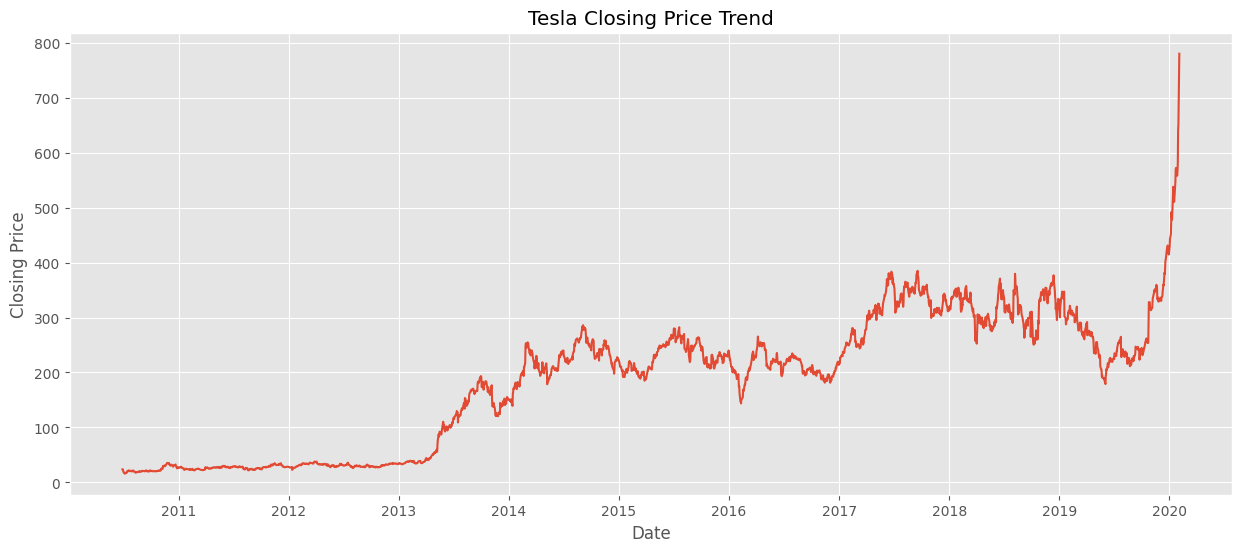

In [16]:
## STEP 5 — EXPLORATORY DATA ANALYSIS

# Tesla Closing Price Over Time

plt.figure(figsize=(15,6))

plt.plot(df['Close'])

plt.title("Tesla Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.show()

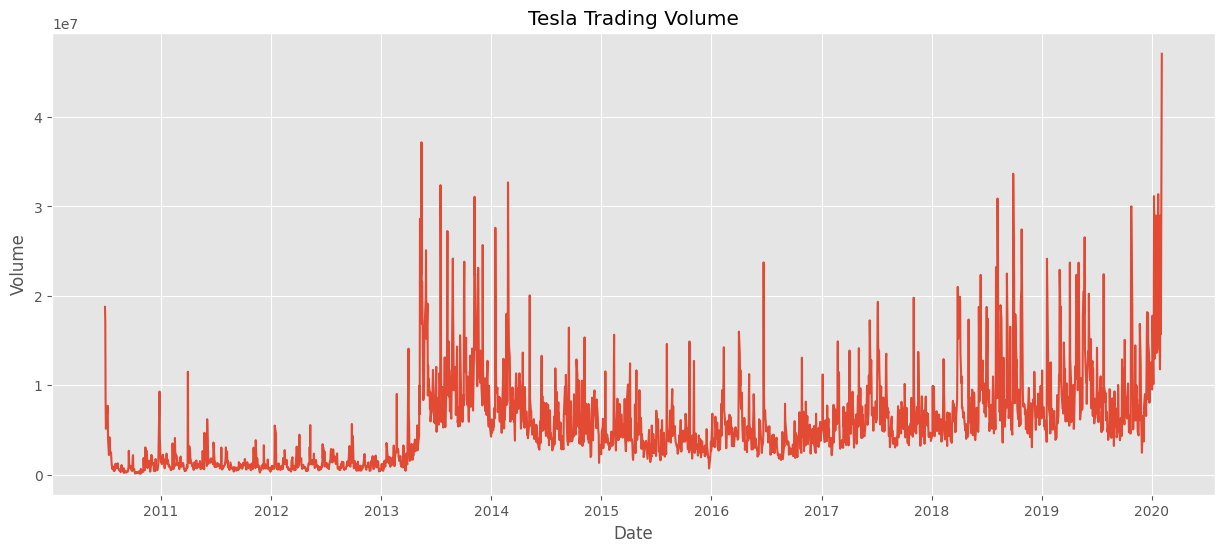

In [17]:
# Volume Traded Over Time

plt.figure(figsize=(15,6))

plt.plot(df['Volume'])

plt.title("Tesla Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume")

plt.show()

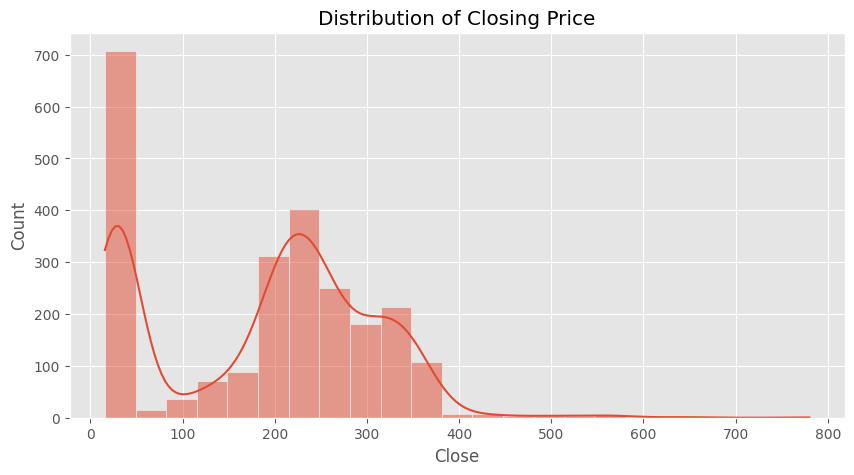

In [18]:
# Distribution of Closing Price

plt.figure(figsize=(10,5))

sns.histplot(df['Close'],
             kde=True)

plt.title("Distribution of Closing Price")

plt.show()

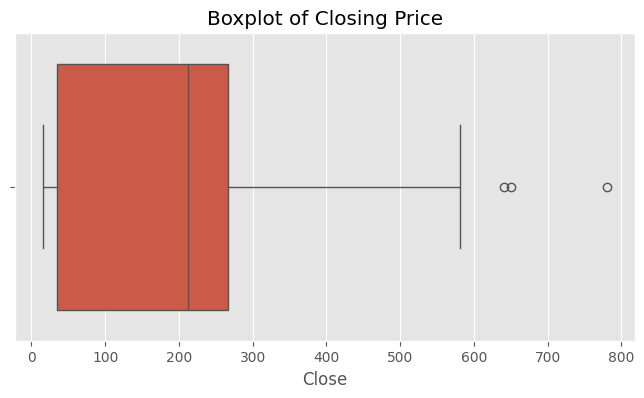

In [19]:
# Detecting Outliers

plt.figure(figsize=(8,4))

sns.boxplot(x=df['Close'])

plt.title("Boxplot of Closing Price")

plt.show()

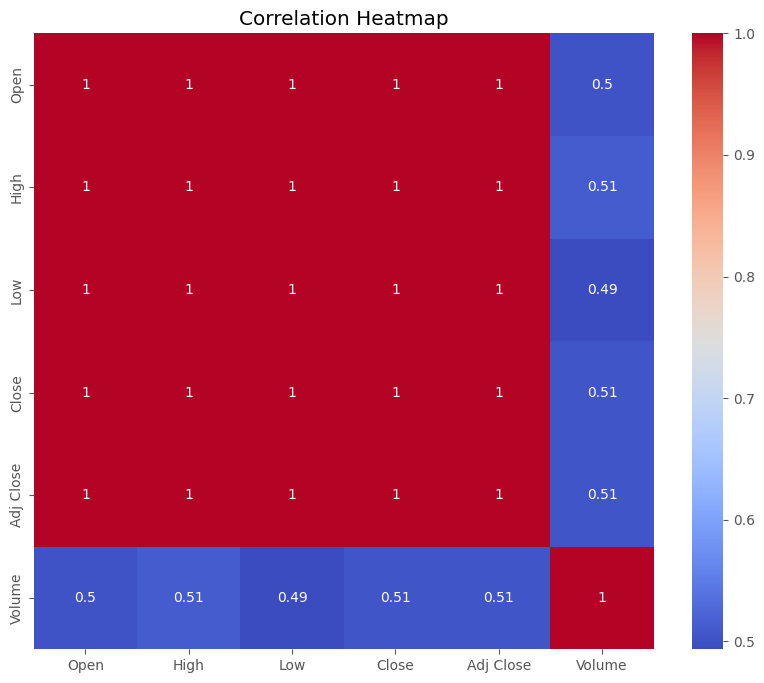

In [20]:
# Correlation Between Features

plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [21]:
## STEP 6 — FEATURE ENGINEERING

# 7-Day Moving Average
df['MA_7'] = df['Close'].rolling(window=7).mean()

In [22]:
# 30-Day Moving Average
df['MA_30'] = df['Close'].rolling(window=30).mean()

In [23]:
# Daily Return Percentage
df['Daily_Return'] = df['Close'].pct_change()

In [24]:
# Volatility Calculation

df['Volatility'] = (
    df['Daily_Return']
    .rolling(window=30)
    .std()
)

In [25]:
# Remove Null Values Generated by Rolling Functions
df.dropna(inplace=True)

In [26]:
# Checking new features
df.head()

,Open,High,Low,Close,Adj Close,Volume,MA_7,MA_30,Daily_Return,Volatility
Date,,,,,,,,,,
2010-08-11,18.690001,18.879999,17.850000,17.900000,17.900000,797600,19.968572,19.841667,-0.059380,0.058080
2010-08-12,17.799999,17.900000,17.389999,17.600000,17.600000,691000,19.347143,19.634000,-0.016760,0.058093
2010-08-13,18.180000,18.450001,17.660000,18.320000,18.320000,634000,18.927143,19.512667,0.040909,0.057207
2010-08-16,18.450001,18.799999,18.260000,18.780001,18.780001,485800,18.688572,19.498667,0.025109,0.052624
2010-08-17,18.959999,19.400000,18.780001,19.150000,19.150000,447900,18.625715,19.600000,0.019702,0.042943


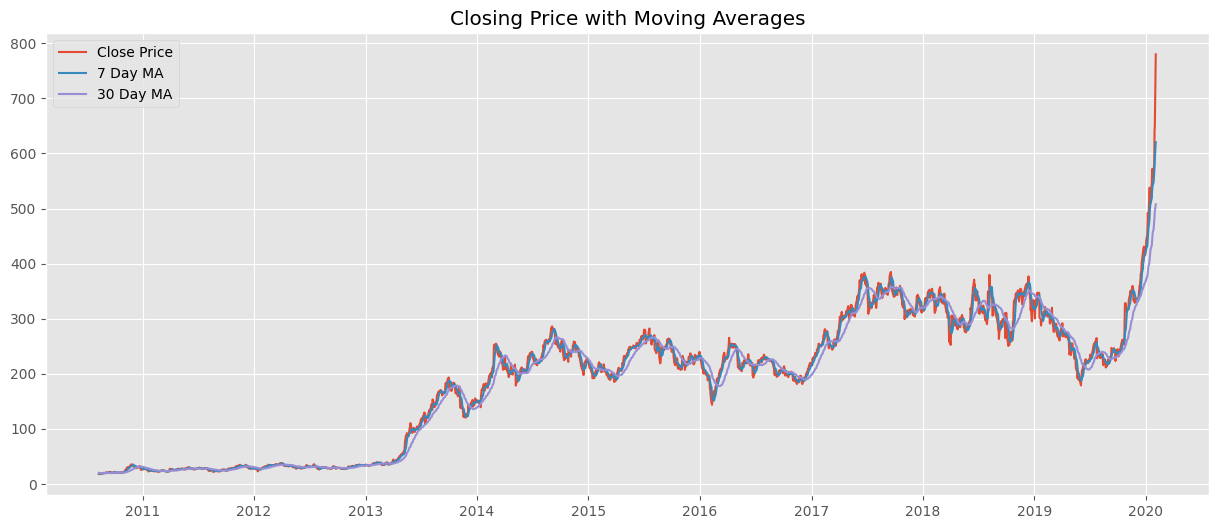

In [28]:
# Moving Average Visualization
plt.figure(figsize=(15,6))

plt.plot(df['Close'],
         label='Close Price')

plt.plot(df['MA_7'],
         label='7 Day MA')

plt.plot(df['MA_30'],
         label='30 Day MA')

plt.legend()

plt.title("Closing Price with Moving Averages")

plt.show()

In [29]:
# Save Cleaned Dataset
df.to_csv("Tesla_Processed.csv")

In [30]:
## STEP 7 — SELECT TARGET VARIABLE

# Preparing Data for Deep Learning Models
# Select Target Variable

data = df[['Close']]
data.head()

,Close
Date,
2010-08-11,17.900000
2010-08-12,17.600000
2010-08-13,18.320000
2010-08-16,18.780001
2010-08-17,19.150000


In [31]:
## STEP 8 — DATA SCALING

 # Scale Data using MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)
print(scaled_data.shape)


(2386, 1)


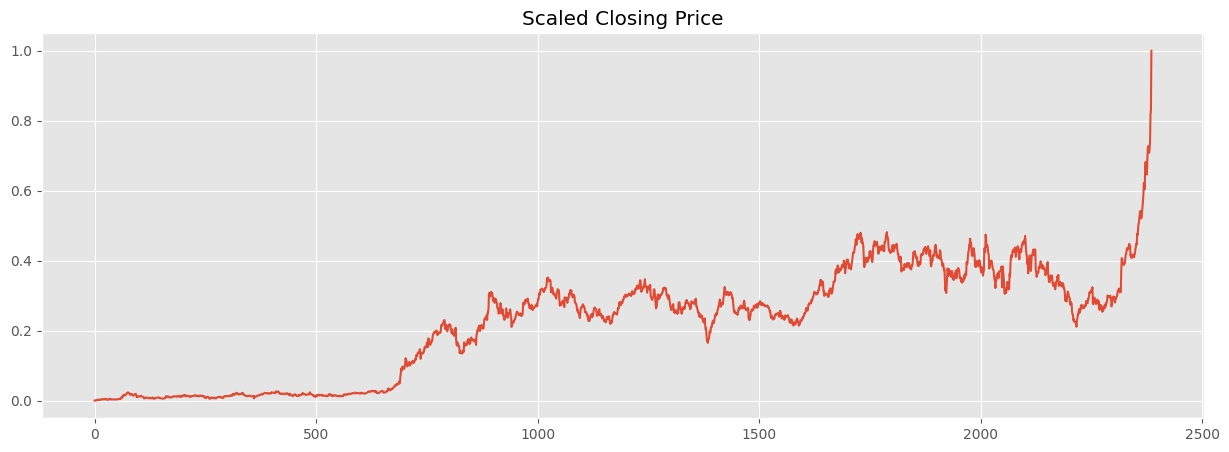

In [32]:
# Visualize Scaled Data

plt.figure(figsize=(15,5))
plt.plot(scaled_data)
plt.title("Scaled Closing Price")
plt.show()

In [33]:
## STEP 9 — CREATE SEQUENCES

# Creating Time Series Sequences
 # Sequence Creation Function

def create_sequences(dataset, time_step=60):

    X = []
    y = []

    for i in range(time_step, len(dataset)):
        X.append(dataset[i-time_step:i, 0])
        y.append(dataset[i, 0])

    return np.array(X), np.array(y)

In [34]:
# Generate Sequences
time_step = 60

X, y = create_sequences(
    scaled_data,
    time_step
)

print(X.shape)
print(y.shape)

(2326, 60)
(2326,)


In [35]:
# Reshaping Data for Deep Learning

X = X.reshape(
    X.shape[0],
    X.shape[1],
    1
)

print(X.shape)

(2326, 60, 1)


In [36]:
## STEP 10 — TRAIN TEST SPLIT

# Train-Test Split

train_size = int(len(X) * 0.80)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print("Training Samples:", len(X_train))
print("Testing Samples :", len(X_test))

Training Samples: 1860
Testing Samples : 466


In [37]:
# Verify Shapes
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(1860, 60, 1)
(466, 60, 1)
(1860,)
(466,)


In [38]:
## STEP 11 — SIMPLE RNN MODEL

# SimpleRNN Model

rnn_model = Sequential()

rnn_model.add(
    SimpleRNN(
        units=50,
        return_sequences=False,
        input_shape=(60,1)
    )
)

rnn_model.add(
    Dropout(0.2)
)

rnn_model.add(
    Dense(1)
)

rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
# Compile Model
rnn_model.compile(
    optimizer='adam',
    loss='mse'
)

In [40]:
# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [41]:
# Train Model
history_rnn = rnn_model.fit(

    X_train,
    y_train,

    validation_data=(
        X_test,
        y_test
    ),

    epochs=50,
    batch_size=32,

    callbacks=[early_stop],

    verbose=1
)

Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - loss: 0.0040 - val_loss: 0.0037
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0013 - val_loss: 0.0024
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9.4932e-04 - val_loss: 0.0015
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9.1736e-04 - val_loss: 0.0014
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.9777e-04 - val_loss: 8.1161e-04
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5.7127e-04 - val_loss: 7.0248e-04
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5.5049e-04 - val_loss: 7.6333e-04
Epoch 8/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5.6212e-04 - val_loss: 0.0015
Epoch 9/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7.1408e-04 - val_loss: 6.1374e-04
Epoch 10/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4.8751e-04 - val_loss: 6.1657e-04
Epoch 11/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4.2970e-04 - val_loss: 5.3566e-04
Epoch 12/50
5

In [42]:
## STEP 12 — RNN PREDICTIONS

# Predict Using SimpleRNN
rnn_predictions = rnn_model.predict(X_test)
print(rnn_predictions.shape)

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
(466, 1)


In [43]:
# Convert Back to Original Scale

rnn_predictions_actual = scaler.inverse_transform(
    rnn_predictions
)
y_test_actual = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

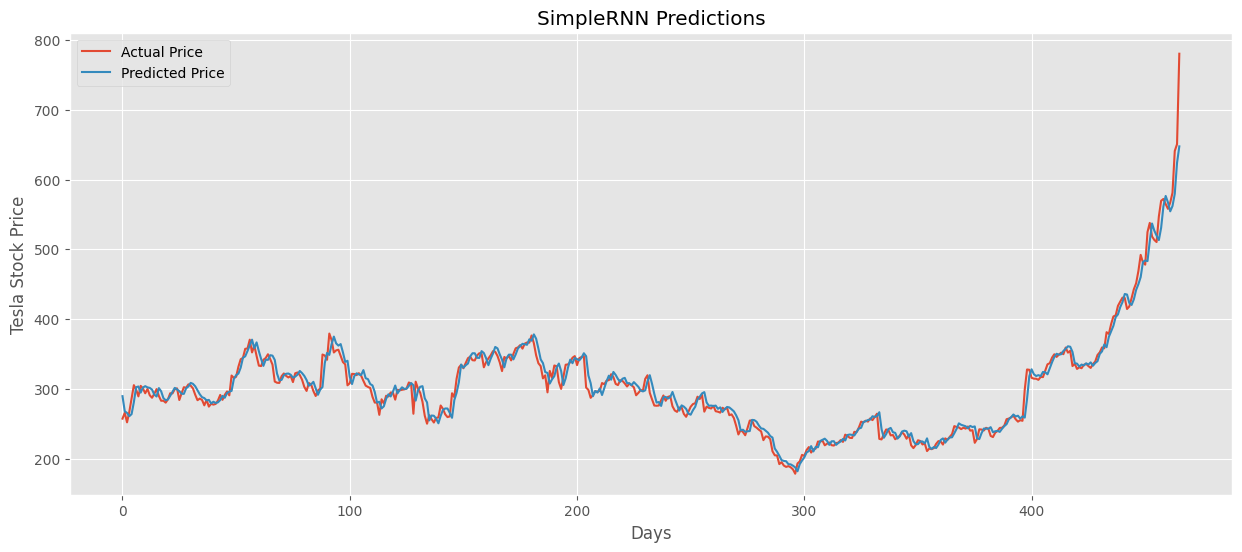

In [44]:
# Visual Comparison
plt.figure(figsize=(15,6))

plt.plot(
    y_test_actual,
    label='Actual Price'
)

plt.plot(
    rnn_predictions_actual,
    label='Predicted Price'
)

plt.title("SimpleRNN Predictions")

plt.xlabel("Days")
plt.ylabel("Tesla Stock Price")

plt.legend()

plt.show()

In [45]:
 # Evaluation Metrics
rnn_mse = mean_squared_error(
    y_test_actual,
    rnn_predictions_actual
)

rnn_rmse = np.sqrt(rnn_mse)

rnn_mae = mean_absolute_error(
    y_test_actual,
    rnn_predictions_actual
)

rnn_r2 = r2_score(
    y_test_actual,
    rnn_predictions_actual
)

print("SimpleRNN Results")
print("-"*40)

print("MSE :", rnn_mse)
print("RMSE:", rnn_rmse)
print("MAE :", rnn_mae)
print("R2  :", rnn_r2)

SimpleRNN Results
----------------------------------------
MSE : 183.57188635669425
RMSE: 13.548870298172252
MAE : 8.754786144954567
R2  : 0.965592689920351


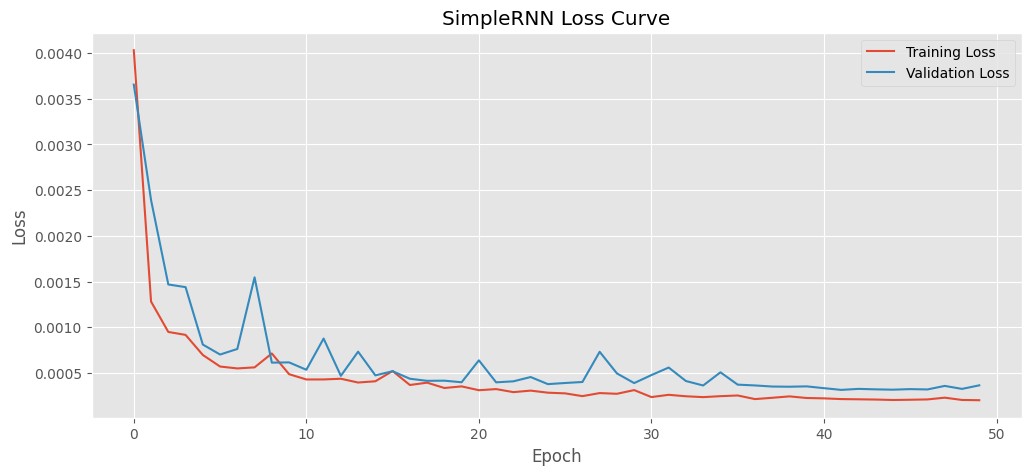

In [46]:
# Training Loss Graph
plt.figure(figsize=(12,5))

plt.plot(
    history_rnn.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_rnn.history['val_loss'],
    label='Validation Loss'
)

plt.title("SimpleRNN Loss Curve")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

In [59]:
## STEP 13 — LSTM MODEL

lstm_model = Sequential()

lstm_model.add(
    LSTM(
        100,
        return_sequences=True,
        input_shape=(60,1)
    )
)

lstm_model.add(
    Dropout(0.2)
)

lstm_model.add(
    LSTM(
        50,
        return_sequences=False
    )
)

lstm_model.add(
    Dropout(0.2)
)

lstm_model.add(
    Dense(25)
)

lstm_model.add(
    Dense(1)
)

lstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 60, 100)        │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 72,301 (282.43 KB)

 Trainable params: 72,301 (282.43 KB)

 Non-trainable params: 0 (0.00 B)

In [60]:
# Compile
lstm_model.compile(
    optimizer='adam',
    loss='mse'
)

In [61]:
# Temporarily Disable EarlyStopping

#Train
history_lstm = lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_test,y_test),
    epochs=30,
    batch_size=32,
    verbose=1
)

Epoch 1/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0034 - val_loss: 0.0020
Epoch 2/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 6.9381e-04 - val_loss: 0.0014
Epoch 3/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.9393e-04 - val_loss: 0.0013
Epoch 4/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.1253e-04 - val_loss: 0.0015
Epoch 5/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.9362e-04 - val_loss: 0.0014
Epoch 6/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.9831e-04 - val_loss: 0.0011
Epoch 7/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.0886e-04 - val_loss: 0.0022
Epoch 8/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3.7895e-04 - val_loss: 0.0012
Epoch 9/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 3.5896e-04 - val_loss: 9.7441e-04
Epoch 10/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3.4846e-04 - val_loss: 9.1107e-04
Epoch 11/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3.5406e-04 - val_loss: 9.3213e-04
Epoch 12/30

In [62]:
len(history_lstm.history['loss'])

30

In [71]:
# LSTM Predictions

lstm_predictions = lstm_model.predict(X_test)
lstm_predictions_actual = scaler.inverse_transform(
    lstm_predictions
)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


In [64]:
# Convert Back To Actual Prices
lstm_predictions_actual = scaler.inverse_transform(
    lstm_predictions
)

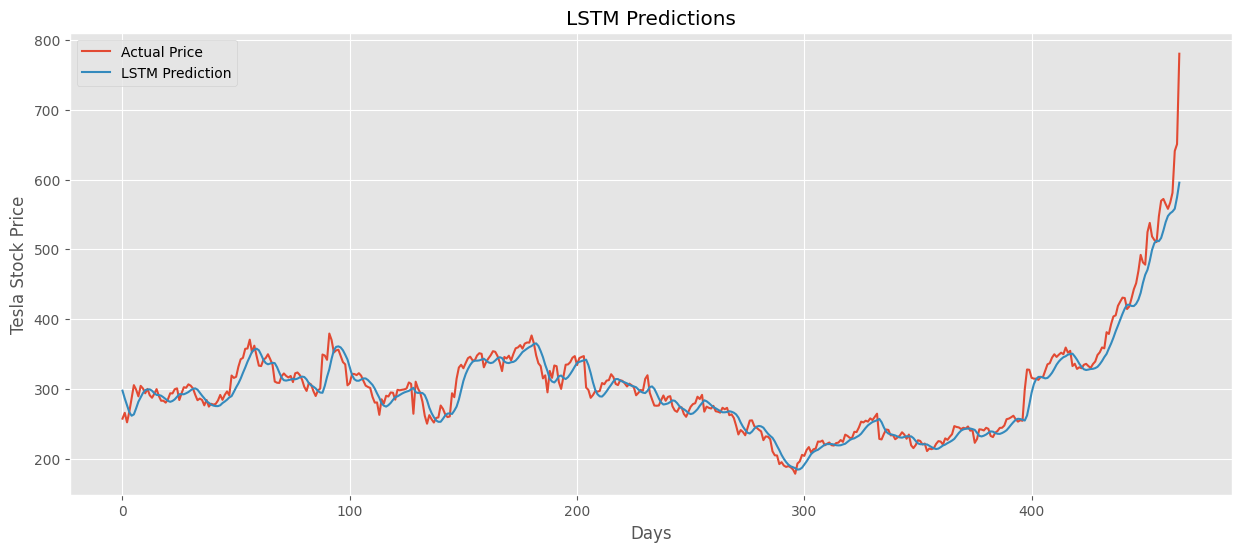

In [65]:
# Plot Predictions
plt.figure(figsize=(15,6))

plt.plot(
    y_test_actual,
    label='Actual Price'
)

plt.plot(
    lstm_predictions_actual,
    label='LSTM Prediction'
)

plt.title("LSTM Predictions")

plt.xlabel("Days")
plt.ylabel("Tesla Stock Price")

plt.legend()

plt.show()

In [73]:
# Calculate Metrics
lstm_mse = mean_squared_error(
    y_test_actual,
    lstm_predictions_actual
)

lstm_rmse = np.sqrt(lstm_mse)

lstm_mae = mean_absolute_error(
    y_test_actual,
    lstm_predictions_actual
)

lstm_r2 = r2_score(
    y_test_actual,
    lstm_predictions_actual
)

print("LSTM Results")
print("-"*40)
print("MSE :", lstm_mse)
print("RMSE:", lstm_rmse)
print("MAE :", lstm_mae)
print("R2  :", lstm_r2)

LSTM Results
----------------------------------------
MSE : 351.5550381948291
RMSE: 18.749801017472933
MAE : 12.440821563811864
R2  : 0.9341072129872394


In [74]:
# Model Comparison Table
comparison = pd.DataFrame({

    "Model":[
        "SimpleRNN",
        "LSTM"
    ],

    "MSE":[
        rnn_mse,
        lstm_mse
    ],

    "RMSE":[
        rnn_rmse,
        lstm_rmse
    ],

    "MAE":[
        rnn_mae,
        lstm_mae
    ],

    "R2 Score":[
        rnn_r2,
        lstm_r2
    ]

})

comparison

,Model,MSE,RMSE,MAE,R2 Score
0,SimpleRNN,183.571886,13.548870,8.754786,0.965593
1,LSTM,351.555038,18.749801,12.440822,0.934107


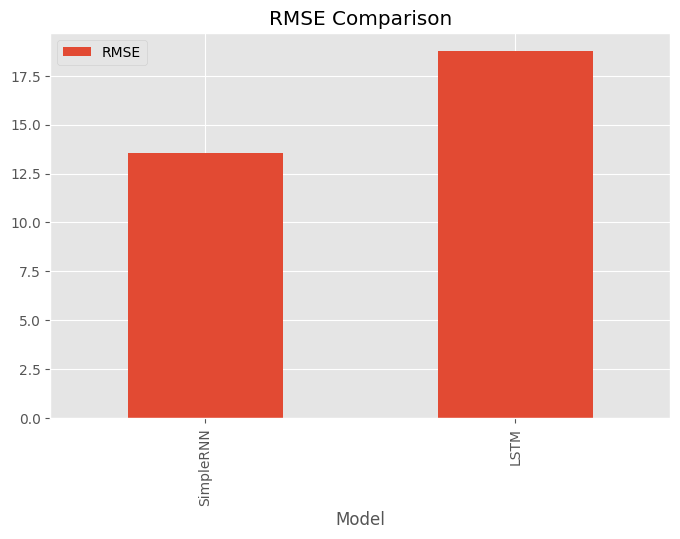

In [75]:
# Better Visualization
comparison.set_index("Model")[
    ["RMSE"]
].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("RMSE Comparison")

plt.show()

In [76]:
## STEP 15 — Future Forecasting

# Last 60 Days Data
last_60_days = scaled_data[-60:]
future_input = last_60_days.reshape(
    1,
    60,
    1
)
future_input.shape

(1, 60, 1)

In [77]:
## STEP 16 — 1 Day Prediction

# 1 Day Ahead Prediction
one_day_prediction = lstm_model.predict(future_input)
one_day_prediction_actual = scaler.inverse_transform(
    one_day_prediction
)
print(
    "Predicted Tesla Closing Price for Next Day:",
    one_day_prediction_actual[0][0]
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
Predicted Tesla Closing Price for Next Day: 641.9249


In [78]:
## STEP 17 — 5 Day Forecast

temp_input = list(last_60_days.flatten())

forecast_5 = []

for i in range(5):

    x_input = np.array(
        temp_input[-60:]
    ).reshape(
        1,
        60,
        1
    )

    yhat = lstm_model.predict(
        x_input,
        verbose=0
    )

    temp_input.append(
        yhat[0][0]
    )

    forecast_5.append(
        yhat[0][0]
    )

forecast_5_actual = scaler.inverse_transform(
    np.array(forecast_5).reshape(-1,1)
)
print("5 Day Forecast")
print(forecast_5_actual)

5 Day Forecast
[[641.9249 ]
 [660.48004]
 [666.1757 ]
 [664.90985]
 [659.8618 ]]


In [79]:
## STEP 18 — 10 Day Forecast

temp_input = list(last_60_days.flatten())

forecast_10 = []

for i in range(10):

    x_input = np.array(
        temp_input[-60:]
    ).reshape(
        1,
        60,
        1
    )

    yhat = lstm_model.predict(
        x_input,
        verbose=0
    )

    temp_input.append(
        yhat[0][0]
    )

    forecast_10.append(
        yhat[0][0]
    )

forecast_10_actual = scaler.inverse_transform(
    np.array(forecast_10).reshape(-1,1)
)
print("10 Day Forecast")
print(forecast_10_actual)

10 Day Forecast
[[641.9249 ]
 [660.48004]
 [666.1757 ]
 [664.90985]
 [659.8618 ]
 [652.8134 ]
 [644.80444]
 [636.46027]
 [628.1607 ]
 [620.1314 ]]


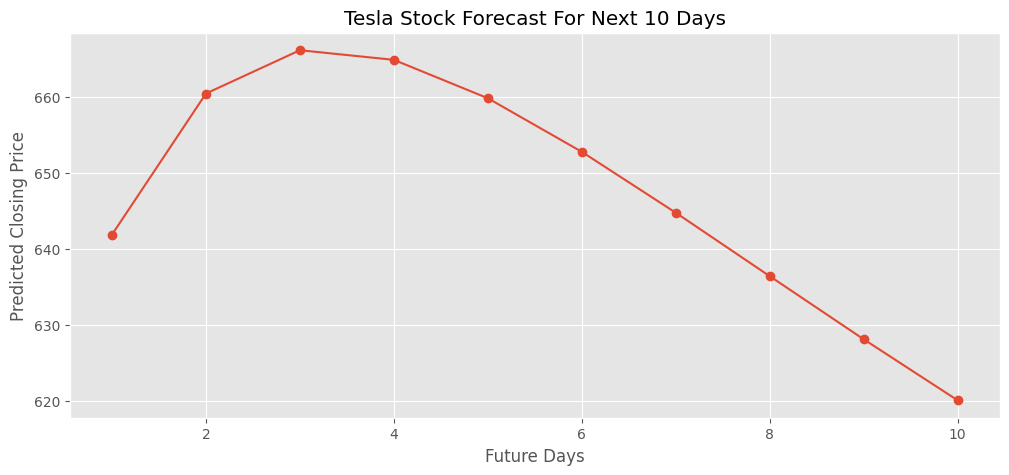

In [80]:
## STEP 19 — Forecast Visualization

# Plot 10 Day Forecast
plt.figure(figsize=(12,5))

plt.plot(
    range(1,11),
    forecast_10_actual,
    marker='o'
)
plt.title(
    "Tesla Stock Forecast For Next 10 Days"
)
plt.xlabel("Future Days")
plt.ylabel("Predicted Closing Price")
plt.grid(True)

plt.show()

**PROJECT CONCLUSION**

1. Tesla stock closing prices were analyzed.
2. Data was preprocessed using MinMaxScaler.
3. Time-series sequences of 60 days were created.
4. SimpleRNN and LSTM models were trained.
5. Model performance was evaluated using:
   - MSE
   - RMSE
   - MAE
   - R2 Score
6. SimpleRNN achieved the best performance.
7. Future stock prices for the next 10 days were forecasted.

Best Model: SimpleRNN
RMSE: 13.55
R2 Score: 0.9656

In [82]:
import joblib

rnn_model.save("model.h5")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']